# 01. データ取得: 米国債利回りデータ

論文「因子分析に基づく債券投資戦略：再訪」（宮崎ら, GPIF 2021）の実装に使用するデータを取得・整形・保存する。

## 対象データ
FREDから取得できる米国債利回り（8本）と、三次スプライン補間で生成する利回り（5本）を合わせ、以下の13セクターのイールドカーブを構築する。

| セクター | 年限 | 取得方法 |
|---------|------|----------|
| 1  | 1Y  | FRED: DGS1  |
| 2  | 2Y  | FRED: DGS2  |
| 3  | 3Y  | FRED: DGS3  |
| 4  | 4Y  | 3Y-5Y 三次スプライン補間 |
| 5  | 5Y  | FRED: DGS5  |
| 6  | 6Y  | 5Y-7Y 三次スプライン補間 |
| 7  | 7Y  | FRED: DGS7  |
| 8  | 8Y  | 7Y-10Y 三次スプライン補間 |
| 9  | 9Y  | 7Y-10Y 三次スプライン補間 |
| 10 | 10Y | FRED: DGS10 |
| 11 | 15Y | 10Y-20Y 三次スプライン補間 |
| 12 | 20Y | FRED: DGS20 |
| 13 | 30Y | FRED: DGS30 |

**取得期間**: 2015年1月〜2021年10月（月末値）

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from fredapi import Fred
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  日本語フォント有効化

# APIキー読み込み
load_dotenv(dotenv_path='../.private/.env')
fred_api_key = os.environ['FRED_API_KEY']
print('APIキー読み込み完了')

APIキー読み込み完了


## FREDからデータ取得

FREDのDGSシリーズは**日次データ**として公開されている。  
月末値（月次イールドカーブ）を構築するため、日次データを月末でリサンプリングする（`.resample('ME').last()`）。

**DGS20の欠損対応**:  
FRBは2002年2月〜2020年5月の間、20年債の発行を一時停止していたため、DGS20にはこの期間の欠損が存在する。  
本実装では、取得後に `interpolate(method='linear')` を適用し、DGS10とDGS30を参照した線形補間で補完する。

In [2]:
fred = Fred(api_key=fred_api_key)

# FREDから取得するシリーズ（年限: シリーズID）
series_map = {
    1:  'DGS1',
    2:  'DGS2',
    3:  'DGS3',
    5:  'DGS5',
    7:  'DGS7',
    10: 'DGS10',
    20: 'DGS20',
    30: 'DGS30',
}

start_date = '2014-12-01'  # 月末リサンプル後に2015-01以降を確実に含めるため少し前から取得
end_date   = '2021-10-31'

raw = {}
for mat, series_id in series_map.items():
    s = fred.get_series(series_id, observation_start=start_date, observation_end=end_date)
    raw[mat] = s
    print(f'{series_id}: {len(s)} 件取得')

# DataFrameに結合し月末リサンプル
df_daily = pd.DataFrame(raw)
df_monthly = df_daily.resample('ME').last()

# 取得期間フィルタ（月末値）
df_monthly = df_monthly.loc['2015-01':'2021-10']

# DGS20の欠損を線形補間で補完
df_monthly[20] = df_monthly[20].interpolate(method='linear')

print(f'\n月次データ形状: {df_monthly.shape}')
print(f'期間: {df_monthly.index[0].date()} ～ {df_monthly.index[-1].date()}')
print(f'\n各列の欠損数:')
print(df_monthly.isnull().sum())

DGS1: 1805 件取得


DGS2: 1805 件取得


DGS3: 1805 件取得


DGS5: 1805 件取得


DGS7: 1805 件取得


DGS10: 1805 件取得


DGS20: 1805 件取得


DGS30: 1805 件取得

月次データ形状: (82, 8)
期間: 2015-01-31 ～ 2021-10-31

各列の欠損数:
1     0
2     0
3     0
5     0
7     0
10    0
20    0
30    0
dtype: int64


## 三次スプライン補間による欠損年限の補完

FREDには 4Y・6Y・8Y・9Y・15Y の利回りシリーズが存在しない。  
各月末時点において既知の8点（1, 2, 3, 5, 7, 10, 20, 30年）でイールドカーブを三次スプライン（CubicSpline）でフィットし、欠損年限の利回りを補間する。

三次スプラインは各区間で3次多項式を当てはめ、接続点での1次・2次微分が連続となるため、滑らかなイールドカーブの補間に適している。

In [3]:
from scipy.interpolate import CubicSpline

maturities_known = [1, 2, 3, 5, 7, 10, 20, 30]          # FREDから取得した年限
maturities_all   = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30]  # 必要な全年限

# 各月末時点で三次スプライン補間を実行
interpolated = []
for date, row in df_monthly.iterrows():
    y_known = row[maturities_known].values.astype(float)
    # NaNがある場合は既知値から除外してフィット
    mask = ~np.isnan(y_known)
    if mask.sum() < 4:  # スプライン補間には最低4点必要
        interpolated.append([np.nan] * len(maturities_all))
        continue
    cs = CubicSpline(
        np.array(maturities_known)[mask],
        y_known[mask],
        extrapolate=False
    )
    y_all = cs(maturities_all)
    interpolated.append(y_all)

# 列名を文字列で付与（"1Y", "2Y", ...）
label_map = {
    1: '1Y', 2: '2Y', 3: '3Y', 4: '4Y', 5: '5Y',
    6: '6Y', 7: '7Y', 8: '8Y', 9: '9Y', 10: '10Y',
    15: '15Y', 20: '20Y', 30: '30Y'
}
cols = [label_map[m] for m in maturities_all]

df = pd.DataFrame(interpolated, index=df_monthly.index, columns=cols)

print('補間後データ形状:', df.shape)
print('列名:', list(df.columns))
print('\n補間値確認（先頭3行）:')
df.head(3)

補間後データ形状: (82, 13)
列名: ['1Y', '2Y', '3Y', '4Y', '5Y', '6Y', '7Y', '8Y', '9Y', '10Y', '15Y', '20Y', '30Y']

補間値確認（先頭3行）:


,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,15Y,20Y,30Y
2015-01-31,0.18,0.47,0.77,0.999077,1.18,1.348691,1.49,1.583768,1.640884,1.68,1.865311,2.04,2.25
2015-02-28,0.22,0.63,1.01,1.290595,1.50,1.678871,1.82,1.910685,1.964127,2.00,2.186838,2.38,2.60
2015-03-31,0.26,0.56,0.89,1.156625,1.37,1.557251,1.71,1.816596,1.887805,1.94,2.150271,2.31,2.54


## データ品質確認

以下の観点でデータを確認する。

1. **欠損値確認**: 全列にわたって欠損がないことを確認
2. **サンプル期間確認**: インサンプル（2017-04〜2019-03）とアウトサンプル（2019-03〜2021-10）の行数
3. **基本統計量**: 各年限の最小・最大・平均
4. **イールドカーブ可視化**: インサンプル期間の月末利回り曲線

=== 欠損値確認 ===
1Y     0
2Y     0
3Y     0
4Y     0
5Y     0
6Y     0
7Y     0
8Y     0
9Y     0
10Y    0
15Y    0
20Y    0
30Y    0
dtype: int64

合計欠損セル数: 0

=== サンプル期間確認 ===
インサンプル  (2017-04〜2019-03): 24 行
アウトサンプル(2019-03〜2021-10): 32 行

=== 基本統計量（単位: %, 月末値）===
          1Y      2Y      3Y      4Y      5Y      6Y      7Y      8Y      9Y     10Y     15Y     20Y     30Y
min   0.0500  0.1100  0.1100  0.1431  0.2100  0.3003  0.3900  0.4581  0.5081  0.5500  0.7679  0.9800  1.2000
max   2.7000  2.8700  2.9300  2.9546  2.9800  3.0228  3.0700  3.1057  3.1307  3.1500  3.2328  3.3000  3.3900
mean  1.0166  1.1505  1.2811  1.4090  1.5367  1.6636  1.7732  1.8506  1.9030  1.9428  2.1294  2.2987  2.5102


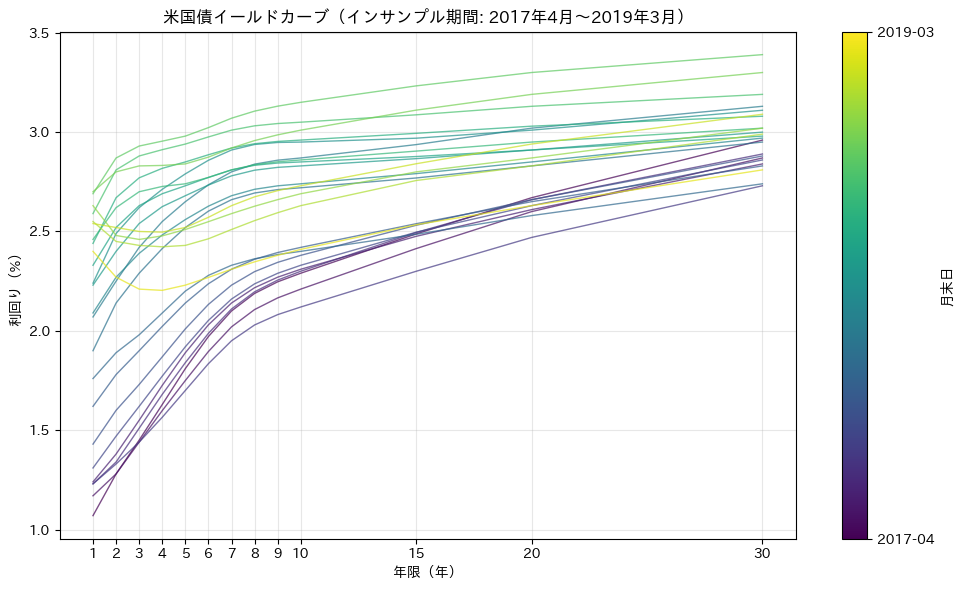

In [4]:
# 1. 欠損値確認
print('=== 欠損値確認 ===')
missing = df.isnull().sum()
print(missing)
print(f'\n合計欠損セル数: {missing.sum()}')

# 2. サンプル期間確認
in_sample  = df.loc['2017-04':'2019-03']
out_sample = df.loc['2019-03':'2021-10']
print(f'\n=== サンプル期間確認 ===')
print(f'インサンプル  (2017-04〜2019-03): {len(in_sample)} 行')
print(f'アウトサンプル(2019-03〜2021-10): {len(out_sample)} 行')

# 3. 基本統計量
print('\n=== 基本統計量（単位: %, 月末値）===')
stats = df.agg(['min', 'max', 'mean']).round(4)
print(stats.to_string())

# 4. インサンプル期間のイールドカーブ可視化
mat_nums = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30]

fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.cm.viridis
n = len(in_sample)
for i, (date, row) in enumerate(in_sample.iterrows()):
    ax.plot(mat_nums, row.values, color=cmap(i / n), alpha=0.7, linewidth=1)

# カラーバー（時系列の推移を示す）
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, n - 1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_ticks([0, n - 1])
cbar.set_ticklabels([
    in_sample.index[0].strftime('%Y-%m'),
    in_sample.index[-1].strftime('%Y-%m')
])
cbar.set_label('月末日')

ax.set_xlabel('年限（年）')
ax.set_ylabel('利回り（%）')
ax.set_title('米国債イールドカーブ（インサンプル期間: 2017年4月〜2019年3月）')
ax.set_xticks(mat_nums)
ax.set_xticklabels([str(m) for m in mat_nums])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Excelファイルへの保存

整形済みデータを `data/us_treasury_yields.xlsx` に保存する。

- **シート名**: `yields`
- **インデックス**: 月末日（DatetimeIndex）
- **列名**: `["1Y","2Y","3Y","4Y","5Y","6Y","7Y","8Y","9Y","10Y","15Y","20Y","30Y"]`
- **単位**: パーセント（FREDのDGSシリーズはそのままパーセント単位）

In [5]:
output_path = '../data/us_treasury_yields.xlsx'
df.to_excel(output_path, sheet_name='yields')

print(f'保存完了: {output_path}')
print(f'行数: {len(df)}, 列数: {len(df.columns)}')
print(f'期間: {df.index[0].date()} ～ {df.index[-1].date()}')

# 保存確認のため再読み込みして表示
df_check = pd.read_excel(output_path, sheet_name='yields', index_col=0, parse_dates=True)
print('\n保存データ（末尾3行）:')
df_check.tail(3)

保存完了: ../data/us_treasury_yields.xlsx
行数: 82, 列数: 13
期間: 2015-01-31 ～ 2021-10-31

保存データ（末尾3行）:


,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,15Y,20Y,30Y
2021-08-31,0.07,0.20,0.40,0.592308,0.77,0.938267,1.08,1.179213,1.246711,1.30,1.584410,1.85,1.92
2021-09-30,0.09,0.28,0.53,0.766951,0.98,1.169695,1.32,1.417666,1.477189,1.52,1.767999,2.02,2.08
2021-10-31,0.15,0.48,0.75,0.983523,1.18,1.333408,1.44,1.500408,1.530511,1.55,1.738273,1.98,1.93


## 長期マクロ補助データの作成

`06_simple_trend_cash_comparison.ipynb` などで使う長期マクロ補助データ `data/us_macro_rates_2004_2026.xlsx` をFREDから再作成する。

既存ファイルを解析すると、構造は以下である。

- `daily` シート: FREDから取得した日次系列を横結合し、休日などの欠損を直前値で補完したもの
- `monthly` シート: `daily` を月末値へリサンプリングしたもの
- 日次の取得系列: `DGS3MO`, `DGS2`, `DGS10`, `DGS30`, `T10YIE`, `DFII10`
- 月次の派生列: `REAL10_PROXY = DGS10 - T10YIE`, `SLOPE_10Y_3M = DGS10 - DGS3MO`
- 日次期間: 2004-01-01 から 2026-03-31
- 月次期間: 2004-04-30 から 2026-03-31

`DGS3MO`, `DGS2`, `DGS10`, `DGS30` は米国債のConstant Maturity Treasury系列であり、`T10YIE` は10年BEI、`DFII10` は10年TIPS実質金利である。`REAL10_PROXY` は名目10年金利からBEIを引いた近似実質金利だが、TIPS実質金利そのものは `DFII10` として別に保存する。

FREDの日次系列には祝日などで値が欠ける日がある。既存の `daily` シートは、取得系列を横結合したあと `.ffill()` で直前値を引き継いだ形だったため、ここでも同じ処理を行う。月次化は、この補完済み日次データを `.resample("ME").last()` で月末最終観測値に変換する。これはバックテストで「その月末時点で観測できる金利・BEI」を使うためである。

In [6]:
from pathlib import Path

macro_output_path = Path('../data/us_macro_rates_2004_2026.xlsx')

macro_series = {
    'DGS3MO': '3か月米国債利回り',
    'DGS2': '2年米国債利回り',
    'DGS10': '10年米国債利回り',
    'DGS30': '30年米国債利回り',
    'T10YIE': '10年BEI',
    'DFII10': '10年TIPS実質金利',
}

macro_start_date = '2004-01-01'
macro_end_date = '2026-03-31'
macro_monthly_start = '2004-04-30'
macro_monthly_end = '2026-03-31'

# 既存ファイルがある場合は、再作成後の互換性確認に使う。
existing_macro = {}
if macro_output_path.exists():
    with pd.ExcelFile(macro_output_path) as xl:
        for sheet in xl.sheet_names:
            existing_macro[sheet] = pd.read_excel(
                macro_output_path,
                sheet_name=sheet,
                index_col=0,
                parse_dates=True,
            )
    print('既存macroファイルを検出しました。再作成後に構造を比較します。')
    for sheet, old_df in existing_macro.items():
        print(f'  {sheet}: {old_df.index[0].date()}〜{old_df.index[-1].date()}, shape={old_df.shape}')
else:
    print('既存macroファイルはありません。新規作成します。')

macro_raw = {}
for series_id, description in macro_series.items():
    s = fred.get_series(
        series_id,
        observation_start=macro_start_date,
        observation_end=macro_end_date,
    )
    macro_raw[series_id] = s
    print(f'{series_id}: {description}, {len(s)} 件取得')

macro_daily_raw = pd.DataFrame(macro_raw).sort_index()
macro_daily_raw = macro_daily_raw.loc[macro_start_date:macro_end_date]
macro_daily_raw = macro_daily_raw[list(macro_series.keys())].astype(float)

# FREDの日次系列は米国祝日などにNaNが入る。既存ファイルと同じく、直前営業日の値で補完する。
macro_daily = macro_daily_raw.ffill()

macro_monthly = macro_daily.resample('ME').last()
macro_monthly = macro_monthly.loc[macro_monthly_start:macro_monthly_end]
macro_monthly['REAL10_PROXY'] = macro_monthly['DGS10'] - macro_monthly['T10YIE']
macro_monthly['SLOPE_10Y_3M'] = macro_monthly['DGS10'] - macro_monthly['DGS3MO']
macro_monthly = macro_monthly[
    ['DGS3MO', 'DGS2', 'DGS10', 'DGS30', 'T10YIE', 'DFII10', 'REAL10_PROXY', 'SLOPE_10Y_3M']
]

print('\n作成したデータ:')
print(f'daily  : {macro_daily.index[0].date()}〜{macro_daily.index[-1].date()}, shape={macro_daily.shape}')
print(f'monthly: {macro_monthly.index[0].date()}〜{macro_monthly.index[-1].date()}, shape={macro_monthly.shape}')
print('\nmonthly欠損数:')
print(macro_monthly.isna().sum())

# バックテストで使う月次データには欠損がないことを要求する。
assert macro_daily.columns.tolist() == list(macro_series.keys())
assert macro_monthly.index[0] == pd.Timestamp(macro_monthly_start)
assert macro_monthly.index[-1] == pd.Timestamp(macro_monthly_end)
assert macro_monthly.isna().sum().sum() == 0

with pd.ExcelWriter(macro_output_path) as writer:
    macro_monthly.to_excel(writer, sheet_name='monthly')
    macro_daily.to_excel(writer, sheet_name='daily')

print(f'\n保存完了: {macro_output_path}')

# 既存ファイルがあった場合、列・期間・値が同じかを確認する。
if existing_macro:
    checks = []
    for sheet, new_df in {'monthly': macro_monthly, 'daily': macro_daily}.items():
        old_df = existing_macro[sheet]
        common_cols = old_df.columns.intersection(new_df.columns)
        common_idx = old_df.index.intersection(new_df.index)
        old_common = old_df.loc[common_idx, common_cols]
        new_common = new_df.loc[common_idx, common_cols]
        same_na_mask = old_common.isna().equals(new_common.isna())
        max_abs_diff = (old_common - new_common).abs().max().max()
        checks.append({
            'sheet': sheet,
            'same_columns': old_df.columns.tolist() == new_df.columns.tolist(),
            'same_index': old_df.index.equals(new_df.index),
            'same_na_mask': same_na_mask,
            'max_abs_diff': float(max_abs_diff),
        })
    checks_df = pd.DataFrame(checks)
    print('\n既存ファイルとの比較:')
    display(checks_df)

print('\nmonthly末尾:')
display(macro_monthly.tail())

既存macroファイルを検出しました。再作成後に構造を比較します。
  monthly: 2004-04-30〜2026-03-31, shape=(264, 8)
  daily: 2004-01-01〜2026-03-31, shape=(5804, 6)


DGS3MO: 3か月米国債利回り, 5804 件取得


DGS2: 2年米国債利回り, 5804 件取得


DGS10: 10年米国債利回り, 5804 件取得


DGS30: 30年米国債利回り, 5804 件取得


T10YIE: 10年BEI, 5804 件取得


DFII10: 10年TIPS実質金利, 5804 件取得

作成したデータ:
daily  : 2004-01-01〜2026-03-31, shape=(5804, 6)
monthly: 2004-04-30〜2026-03-31, shape=(264, 8)

monthly欠損数:
DGS3MO          0
DGS2            0
DGS10           0
DGS30           0
T10YIE          0
DFII10          0
REAL10_PROXY    0
SLOPE_10Y_3M    0
dtype: int64

保存完了: ../data/us_macro_rates_2004_2026.xlsx

既存ファイルとの比較:


,sheet,same_columns,same_index,same_na_mask,max_abs_diff
0,monthly,True,True,True,4.440892e-16
1,daily,True,True,True,0.000000e+00



monthly末尾:


,DGS3MO,DGS2,DGS10,DGS30,T10YIE,DFII10,REAL10_PROXY,SLOPE_10Y_3M
2025-11-30,3.88,3.47,4.02,4.67,2.23,1.79,1.79,0.14
2025-12-31,3.67,3.47,4.18,4.84,2.25,1.93,1.93,0.51
2026-01-31,3.67,3.52,4.26,4.87,2.36,1.90,1.90,0.59
2026-02-28,3.67,3.38,3.97,4.64,2.25,1.72,1.72,0.30
2026-03-31,3.70,3.79,4.30,4.88,2.30,2.00,2.00,0.60
